In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Setup environment

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)

DATASET_DIR = "/content/drive/MyDrive/anomalias_copy/dataset/windowed/"
MODEL_DIR = "/content/drive/MyDrive/anomalias_copy/LSTM_classifcator_mul_ver11/"
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Dataset dir: {DATASET_DIR}")
print(f"Model dir: {MODEL_DIR}")

Dataset dir: /content/drive/MyDrive/anomalias_copy/dataset/windowed/
Model dir: /content/drive/MyDrive/anomalias_copy/LSTM_classifcator_mul_ver11/


In [ ]:
!pip install optuna scikit-learn -q

import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

print(f"TensorFlow version: {tf.__version__}")
print(f"Optuna version: {optuna.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.6 MB/s eta 0:00:00
TensorFlow version: 2.19.0
Optuna version: 4.7.0


#Load and explore dataset

In [ ]:
try:
    X = np.load(os.path.join(DATASET_DIR, "X_windows.npy"))
    y_bin = np.load(os.path.join(DATASET_DIR, "y_binary.npy"))
    y_ch = np.load(os.path.join(DATASET_DIR, "y_channel.npy"))

    print("Dataset loaded successfully")
    print(f"X shape: {X.shape}")
    print(f"y_binary shape: {y_bin.shape}")
    print(f"y_channel shape: {y_ch.shape}")

    # Class information
    unique_classes = np.unique(y_ch)
    print(f"\nUnique classes in y_channel: {unique_classes}")
    print(f"Total number of classes: {len(unique_classes)}")

    # Class distribution
    class_counts = {int(cls): int(np.sum(y_ch == cls)) for cls in unique_classes}
    print("\nClass distribution:")
    for cls, count in class_counts.items():
        print(f"  Class {cls}: {count} samples ({count/len(y_ch)*100:.2f}%)")

except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset loaded successfully
X shape: (399981, 20, 16)
y_binary shape: (399981,)
y_channel shape: (399981,)

Unique classes in y_channel: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
Total number of classes: 19

Class distribution:
  Class 0: 125011 samples (31.25%)
  Class 1: 15353 samples (3.84%)
  Class 2: 16409 samples (4.10%)
  Class 3: 15456 samples (3.86%)
  Class 4: 15986 samples (4.00%)
  Class 5: 14490 samples (3.62%)
  Class 6: 15145 samples (3.79%)
  Class 7: 26408 samples (6.60%)
  Class 8: 10228 samples (2.56%)
  Class 9: 9526 samples (2.38%)
  Class 10: 25653 samples (6.41%)
  Class 11: 10068 samples (2.52%)
  Class 12: 10171 samples (2.54%)
  Class 13: 25949 samples (6.49%)
  Class 14: 9091 samples (2.27%)
  Class 15: 10341 samples (2.59%)
  Class 16: 14716 samples (3.68%)
  Class 17: 14576 samples (3.64%)
  Class 18: 15404 samples (3.85%)


#Preprocessing - Scaling using only normal data

In [ ]:
normal_class = 0
normal_mask = y_ch == normal_class

if np.sum(normal_mask) > 0:
    X_nom = X[normal_mask]
    print(f"Normal windows identified: {len(X_nom)}")

    # Calculate mean and std only from normal data
    mean_feat = X_nom.mean(axis=(0, 1))
    std_feat = X_nom.std(axis=(0, 1)) + 1e-8

    def scale_windows(X, mean, std):
        return (X - mean[None, None, :]) / std[None, None, :]

    X_scaled = scale_windows(X, mean_feat, std_feat)

    print(f"\nX_scaled shape: {X_scaled.shape}")
    print(f"X_scaled mean: {X_scaled.mean():.4f}")
    print(f"X_scaled std: {X_scaled.std():.4f}")
else:
    print("No normal data found, using standard scaling")
    # Standard scaling using all data
    X_scaled = (X - X.mean(axis=(0, 1, 2))) / (X.std(axis=(0, 1, 2)) + 1e-8)

Normal windows identified: 125011

X_scaled shape: (399981, 20, 16)
X_scaled mean: 0.0106
X_scaled std: 0.9780


#Prepare data for multiclass classification

In [ ]:
EXCLUDE_NORMAL = True

if EXCLUDE_NORMAL:
    anomaly_mask = y_ch > 0
    X_multi = X_scaled[anomaly_mask]
    y_multi = y_ch[anomaly_mask]

    unique_classes = np.unique(y_multi)
    class_mapping = {orig: new for new, orig in enumerate(unique_classes)}
    y_multi_remapped = np.vectorize(class_mapping.get)(y_multi)

    num_classes = len(unique_classes)

    print(f"Training only with anomaly classes")
    print(f"  Total samples: {len(X_multi)}")
    print(f"  Number of classes: {num_classes}")
    print(f"  Original classes: {unique_classes}")
    print(f"  Mapping to new labels: {class_mapping}")

else:
    X_multi = X_scaled
    y_multi = y_ch
    num_classes = len(np.unique(y_multi))

    print(f"Training with all classes (including normal)")
    print(f"  Total samples: {len(X_multi)}")
    print(f"  Number of classes: {num_classes}")

print("\nClass distribution:")
unique, counts = np.unique(y_multi_remapped if EXCLUDE_NORMAL else y_multi, return_counts=True)
for cls, count in zip(unique, counts):
    percentage = count / len(y_multi_remapped if EXCLUDE_NORMAL else y_multi) * 100
    print(f"  Class {cls}: {count} samples ({percentage:.2f}%)")

Training only with anomaly classes
  Total samples: 274970
  Number of classes: 18
  Original classes: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
  Mapping to new labels: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5, np.int64(7): 6, np.int64(8): 7, np.int64(9): 8, np.int64(10): 9, np.int64(11): 10, np.int64(12): 11, np.int64(13): 12, np.int64(14): 13, np.int64(15): 14, np.int64(16): 15, np.int64(17): 16, np.int64(18): 17}

Class distribution (after remapping if applicable):
  Class 0: 15353 samples (5.58%)
  Class 1: 16409 samples (5.97%)
  Class 2: 15456 samples (5.62%)
  Class 3: 15986 samples (5.81%)
  Class 4: 14490 samples (5.27%)
  Class 5: 15145 samples (5.51%)
  Class 6: 26408 samples (9.60%)
  Class 7: 10228 samples (3.72%)
  Class 8: 9526 samples (3.46%)
  Class 9: 25653 samples (9.33%)
  Class 10: 10068 samples (3.66%)
  Class 11: 10171 samples (3.70%)
  Class 12: 25949 samples (9.44%)
  Class 13: 9091 samples (

#Data Split

In [ ]:
print("DATA SPLITTING")
y_labels = y_multi_remapped if EXCLUDE_NORMAL else y_multi

# First split: 70% train, 30% temp
X_temp, X_test, y_temp, y_test = train_test_split(
    X_multi, y_labels,
    test_size=0.15,
    random_state=SEED,
    stratify=y_labels
)

# Second split: 15% val, 15% test from original (from the 30%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Data split successfully")
print(f"  Train: {len(X_train)} samples ({len(X_train)/len(X_multi)*100:.1f}%)")
print(f"  Val:   {len(X_val)} samples ({len(X_val)/len(X_multi)*100:.1f}%)")
print(f"  Test:  {len(X_test)} samples ({len(X_test)/len(X_multi)*100:.1f}%)")

print("\nClass distribution in Train:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, count in zip(unique_train, counts_train):
    print(f"  Class {cls}: {count} samples")

DATA SPLITTING
Data split successfully
  Train: 116862 samples (42.5%)
  Val:   116862 samples (42.5%)
  Test:  41246 samples (15.0%)

Class distribution in Train:
  Class 0: 6525 samples
  Class 1: 6974 samples
  Class 2: 6569 samples
  Class 3: 6794 samples
  Class 4: 6158 samples
  Class 5: 6437 samples
  Class 6: 11223 samples
  Class 7: 4347 samples
  Class 8: 4049 samples
  Class 9: 10902 samples
  Class 10: 4279 samples
  Class 11: 4322 samples
  Class 12: 11029 samples
  Class 13: 3863 samples
  Class 14: 4395 samples
  Class 15: 6255 samples
  Class 16: 6195 samples
  Class 17: 6546 samples


# Calculate class weights for balancing

In [ ]:
# Calculate class weights
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = {int(cls): weight for cls, weight in zip(classes, weights)}
print("Calculated weights for each class:")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.3f}")

Calculated weights for each class:
  Class 0: 0.995
  Class 1: 0.931
  Class 2: 0.988
  Class 3: 0.956
  Class 4: 1.054
  Class 5: 1.009
  Class 6: 0.578
  Class 7: 1.494
  Class 8: 1.603
  Class 9: 0.596
  Class 10: 1.517
  Class 11: 1.502
  Class 12: 0.589
  Class 13: 1.681
  Class 14: 1.477
  Class 15: 1.038
  Class 16: 1.048
  Class 17: 0.992


#LSTM Model Architecture

In [ ]:
def build_lstm_multiclass_model(
    input_shape,
    num_classes,
    lstm_units=128,
    n_layers=2,
    dropout_rate=0.3,
    dense_units=64,
    learning_rate=0.001
):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    for i in range(n_layers):
        return_sequences = i < (n_layers - 1)
        model.add(layers.LSTM(
            lstm_units,
            return_sequences=return_sequences,
            kernel_regularizer=keras.regularizers.l2(0.001)
        ))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate/2))

    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision', top_k=1),
            keras.metrics.Recall(name='recall', top_k=1)
        ]
    )

    return model

print("Model architecture:")
input_shape = X_train.shape[1:]
test_model = build_lstm_multiclass_model(input_shape, num_classes)
test_model.summary()

Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,250 (840.82 KB)

 Trainable params: 215,250 (840.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class MulticlassMetricsCallback(callbacks.Callback):
    def __init__(self, X_val, y_val, patience=10):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.patience = patience
        self.best_f1 = 0
        self.best_weights = None
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        y_pred_proba = self.model.predict(self.X_val, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)

        f1_macro = f1_score(self.y_val, y_pred, average='macro', zero_division=0)
        precision = precision_score(self.y_val, y_pred, average='macro', zero_division=0)
        recall = recall_score(self.y_val, y_pred, average='macro', zero_division=0)

        if f1_macro > self.best_f1:
            self.best_f1 = f1_macro
            self.best_weights = self.model.get_weights()
            self.wait = 0
            print(f"  ✓ New best F1: {f1_macro:.4f}")
        else:
            self.wait += 1

        if self.wait >= self.patience:
            self.model.stop_training = True
            self.model.set_weights(self.best_weights)
            print(f"\n⚠ Early stopping at epoch {epoch+1}")
            print(f"  Restoring weights with F1: {self.best_f1:.4f}")

        logs['val_f1_macro'] = f1_macro
        logs['val_precision_macro'] = precision
        logs['val_recall_macro'] = recall

        print(f"  Epoch {epoch+1} - F1: {f1_macro:.4f}, Prec: {precision:.4f}, Rec: {recall:.4f}")

#Hyperparameter optimization with Optuna

In [ ]:
def objective_multiclass_optuna(trial):
    tf.keras.backend.clear_session()

    lstm_units = trial.suggest_categorical("lstm_units", [64, 128, 192, 256])
    n_layers = trial.suggest_int("n_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5, step=0.1)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    dense_units = trial.suggest_categorical("dense_units", [32, 64, 128])

    model = models.Sequential()
    model.add(layers.Input(shape=X_train.shape[1:]))

    for i in range(n_layers):
        return_sequences = i < (n_layers - 1)
        model.add(layers.LSTM(
            lstm_units,
            return_sequences=return_sequences,
            kernel_regularizer=keras.regularizers.l2(0.001)
        ))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate/2))

    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']  # Only accuracy during optimization
    )

    class OptunaCallback(callbacks.Callback):
        def __init__(self):
            super().__init__()
            self.best_f1 = 0

        def on_epoch_end(self, epoch, logs=None):
            y_pred_proba = self.model.predict(X_val, verbose=0)
            y_pred = np.argmax(y_pred_proba, axis=1)

            if len(y_pred.shape) > 1:
                y_pred = np.squeeze(y_pred)
            if len(y_val.shape) > 1:
                y_true = np.squeeze(y_val)
            else:
                y_true = y_val

            min_len = min(len(y_pred), len(y_true))
            y_pred = y_pred[:min_len]
            y_true = y_true[:min_len]

            f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

            if f1_macro > self.best_f1:
                self.best_f1 = f1_macro

    f1_callback = OptunaCallback()

    try:
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=15,
            batch_size=batch_size,
            class_weight=class_weight_dict,
            callbacks=[f1_callback],
            verbose=0
        )

        trial.set_user_attr("best_f1", float(f1_callback.best_f1))
        return f1_callback.best_f1

    except Exception as e:
        print(f"Trial failed: {e}")
        return 0.0

def safe_objective(trial):
    try:
        return objective_multiclass_optuna(trial)
    except Exception as e:
        print(f"Trial {trial.number} failed with error: {str(e)[:100]}...")
        return 0.0

# Create Optuna study
study = optuna.create_study(
    direction="maximize",
    study_name="lstm_multiclass_optimization",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

print("Starting hyperparameter optimization")
print(f"Will evaluate {20} different configurations")

try:
    study.optimize(safe_objective, n_trials=20, show_progress_bar=True)
except Exception as e:
    print(f"Optimization failed: {e}")
    print("Trying alternative approach...")

    n_trials = 20
    for trial_idx in range(n_trials):
        try:
            trial = optuna.trial.FixedTrial({
                "lstm_units": [64, 128, 192, 256][trial_idx % 4],
                "n_layers": trial_idx % 3 + 1,
                "dropout_rate": 0.2 + (trial_idx % 4) * 0.1,
                "learning_rate": 10**(-4 - (trial_idx % 3) * 0.5),
                "batch_size": [32, 64, 128][trial_idx % 3],
                "dense_units": [32, 64, 128][trial_idx % 3]
            })

            score = safe_objective(trial)
            print(f"Trial {trial_idx+1}/{n_trials}: Score = {score:.4f}")

        except Exception as e:
            print(f"Trial {trial_idx+1} failed: {e}")
            continue

print("OPTUNA RESULTS")
if study.trials:
    print(f"Best F1 Macro: {study.best_value:.4f}")
    print(f"Best hyperparameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
else:
    print("No successful trials. Using default parameters.")
    best_params = {
        "lstm_units": 128,
        "n_layers": 2,
        "dropout_rate": 0.3,
        "learning_rate": 0.001,
        "batch_size": 64,
        "dense_units": 64
    }

[I 2026-01-23 21:31:15,092] A new study created in memory with name: lstm_multiclass_optimization


Starting hyperparameter optimization
Will evaluate 20 different configurations


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-01-23 21:42:41,436] Trial 0 finished with value: 0.23812613502359506 and parameters: {'lstm_units': 128, 'n_layers': 1, 'dropout_rate': 0.2, 'learning_rate': 0.00013066739238053285, 'batch_size': 32, 'dense_units': 64}. Best is trial 0 with value: 0.23812613502359506.
[I 2026-01-23 21:57:01,291] Trial 1 finished with value: 0.2480505853312734 and parameters: {'lstm_units': 256, 'n_layers': 2, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0003823475224675188, 'batch_size': 32, 'dense_units': 128}. Best is trial 1 with value: 0.2480505853312734.
[I 2026-01-23 22:05:34,024] Trial 2 finished with value: 0.25463873893135797 and parameters: {'lstm_units': 192, 'n_layers': 2, 'dropout_rate': 0.2, 'learning_rate': 0.00013492834268013249, 'batch_size': 64, 'dense_units': 128}. Best is trial 2 with value: 0.25463873893135797.
[I 2026-01-23 22:13:10,755] Trial 3 finished with value: 0.1302372822469338 and parameters: {'lstm_units': 192, 'n_layers': 3, 'dropout_rate': 0.300000000

#Train final model with best Hyperparameters

In [ ]:
best_params = study.best_params

print("Building final model with best hyperparameters")
model_final = models.Sequential()
model_final.add(layers.Input(shape=X_train.shape[1:]))

for i in range(best_params['n_layers']):
    return_sequences = i < (best_params['n_layers'] - 1)
    model_final.add(layers.LSTM(
        best_params['lstm_units'],
        return_sequences=return_sequences,
        kernel_regularizer=keras.regularizers.l2(0.001)
    ))
    model_final.add(layers.Dropout(best_params['dropout_rate']))

model_final.add(layers.Dense(best_params['dense_units'], activation='relu'))
model_final.add(layers.Dropout(best_params['dropout_rate']/2))

model_final.add(layers.Dense(num_classes, activation='softmax'))

model_final.compile(
    optimizer=optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_final.summary()

class FixedMulticlassCallback(callbacks.Callback):
    def __init__(self, X_val, y_val, patience=10):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.patience = patience
        self.best_f1 = 0
        self.best_weights = None
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        y_pred_proba = self.model.predict(self.X_val, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)

        if len(y_pred) != len(self.y_val):
            min_len = min(len(y_pred), len(self.y_val))
            y_pred = y_pred[:min_len]
            y_true = self.y_val[:min_len]
        else:
            y_true = self.y_val

        f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
        precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

        logs['val_f1_macro'] = f1_macro
        logs['val_precision_macro'] = precision
        logs['val_recall_macro'] = recall

        if f1_macro > self.best_f1:
            self.best_f1 = f1_macro
            self.best_weights = self.model.get_weights()
            self.wait = 0
            print(f"  New best F1: {f1_macro:.4f} (Prec: {precision:.4f}, Rec: {recall:.4f})")
        else:
            self.wait += 1
            print(f"  Epoch {epoch+1} - F1: {f1_macro:.4f}, Prec: {precision:.4f}, Rec: {recall:.4f}")

        if self.wait >= self.patience:
            self.model.stop_training = True
            self.model.set_weights(self.best_weights)
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"  Restoring weights with F1: {self.best_f1:.4f}")

checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, 'best_model.keras'),
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

fixed_callback = FixedMulticlassCallback(X_val, y_val, patience=10)

print("\nStarting final training")
try:
    history_final = model_final.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=best_params['batch_size'],
        class_weight=class_weight_dict,
        callbacks=[fixed_callback, early_stopping, reduce_lr, checkpoint],
        verbose=1
    )

    model_final.save(os.path.join(MODEL_DIR, 'lstm_multiclass_final.keras'))
    print(f"\n Model saved to: {os.path.join(MODEL_DIR, 'lstm_multiclass_final.keras')}")

    # Update history with our custom metrics
    if not hasattr(history_final, 'history'):
        history_final.history = {}

    history_final.history['val_f1_macro'] = []
    history_final.history['val_precision_macro'] = []
    history_final.history['val_recall_macro'] = []

except Exception as e:
    print(f"Error during training: {e}")
    print("\nTrying alternative approach without complex callbacks...")

    # Fallback: Simple training
    history_final = model_final.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=best_params['batch_size'],
        class_weight=class_weight_dict,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Save model
    model_final.save(os.path.join(MODEL_DIR, 'lstm_multiclass_final_simple.keras'))
    print(f"\n Model saved to: {os.path.join(MODEL_DIR, 'lstm_multiclass_final_simple.keras')}")

print("\nCreating evaluation model with full metrics")
eval_model = models.Sequential()
eval_model.add(layers.Input(shape=X_train.shape[1:]))

for i in range(best_params['n_layers']):
    return_sequences = i < (best_params['n_layers'] - 1)
    eval_model.add(layers.LSTM(
        best_params['lstm_units'],
        return_sequences=return_sequences,
        kernel_regularizer=keras.regularizers.l2(0.001)
    ))
    eval_model.add(layers.Dropout(0))

eval_model.add(layers.Dense(best_params['dense_units'], activation='relu'))
eval_model.add(layers.Dense(num_classes, activation='softmax'))

eval_model.load_weights(os.path.join(MODEL_DIR, 'best_model.keras'))

eval_model.compile(
    optimizer=optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Evaluation model ready for testing")

Building final model with best hyperparameters


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 128)            │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,074 (363.57 KB)

 Trainable params: 93,074 (363.57 KB)

 Non-trainable params: 0 (0.00 B)


Starting final training
Epoch 1/50
906/913 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1388 - loss: 2.7404  New best F1: 0.1664 (Prec: 0.1862, Rec: 0.1920)

Epoch 1: val_loss improved from inf to 2.62930, saving model to /content/drive/MyDrive/anomalias_copy/LSTM_classifcator_mul_ver11/best_model.keras
913/913 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.1390 - loss: 2.7399 - val_accuracy: 0.1793 - val_loss: 2.6293 - val_f1_macro: 0.1664 - val_precision_macro: 0.1862 - val_recall_macro: 0.1920 - learning_rate: 6.1333e-04
Epoch 2/50
909/913 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1818 - loss: 2.6166  New best F1: 0.1878 (Prec: 0.1906, Rec: 0.2022)

Epoch 2: val_loss improved from 2.62930 to 2.58376, saving model to /content/drive/MyDrive/anomalias_copy/LSTM_classifcator_mul_ver11/best_model.keras
913/913 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.1818 - loss: 2.6165 - val_accuracy: 0.2026 - val_loss: 2.5838 - val_f1_macro: 0.1878 - val_precision_macro: 0.1906 - val_

#Test set evaluation

In [ ]:
best_model = keras.models.load_model(os.path.join(MODEL_DIR, 'best_model.keras'))
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

if EXCLUDE_NORMAL:
    class_names = [str(i) for i in range(num_classes)]
else:
    class_names = ['0'] + [str(i) for i in range(1, num_classes)]

print("CLASSIFICATION REPORT")

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))

print("REQUIRED METRICS")

from sklearn.metrics import hamming_loss

accuracy = accuracy_score(y_test, y_pred)

micro_f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

hamming = hamming_loss(y_test, y_pred)

print(f"{'Metric':<25} {'Value':<15} ")
print(f"{'Accuracy':<25} {accuracy:.6f} ")
print(f"{'Hamming Loss':<25} {hamming:.6f} ")
print(f"{'Micro-F1 Score':<25} {micro_f1:.6f} ")
print(f"{'Macro-F1 Score':<25} {macro_f1:.6f} ")
print(f"{'Weighted F1 Score':<25} {weighted_f1:.6f} ")

micro_precision = precision_score(y_test, y_pred, average='micro', zero_division=0)
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
micro_recall = recall_score(y_test, y_pred, average='micro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\n{'Additional Metrics':<25} {'Value':<15}")
print(f"{'Micro Precision':<25} {micro_precision:.6f}")
print(f"{'Macro Precision':<25} {macro_precision:.6f}")
print(f"{'Micro Recall':<25} {micro_recall:.6f}")
print(f"{'Macro Recall':<25} {macro_recall:.6f}")

print("METRICS COMPARISON")

if 'study' in locals() and study.best_value:
    val_f1_macro = study.best_value
    f1_diff = macro_f1 - val_f1_macro
    print(f"Validation Macro-F1 (Optuna): {val_f1_macro:.6f}")
    print(f"Test Macro-F1:                {macro_f1:.6f}")
    print(f"Difference:                   {f1_diff:+.6f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.2872    0.2562    0.2708      2303
           1     0.3003    0.1881    0.2313      2461
           2     0.2624    0.2251    0.2423      2319
           3     0.3082    0.2219    0.2580      2398
           4     0.2436    0.2282    0.2356      2174
           5     0.2179    0.1831    0.1990      2272
           6     0.3412    0.0770    0.1256      3961
           7     0.1819    0.4198    0.2538      1534
           8     0.1845    0.4213    0.2566      1429
           9     0.6690    0.3035    0.4176      3848
          10     0.2163    0.3834    0.2766      1510
          11     0.1959    0.3414    0.2490      1526
          12     0.7297    0.2539    0.3767      3892
          13     0.1786    0.4956    0.2626      1364
          14     0.2045    0.3991    0.2704      1551
          15     0.7189    0.7485    0.7334      2207
          16     0.7214    0.7722    0.7459      2186
     

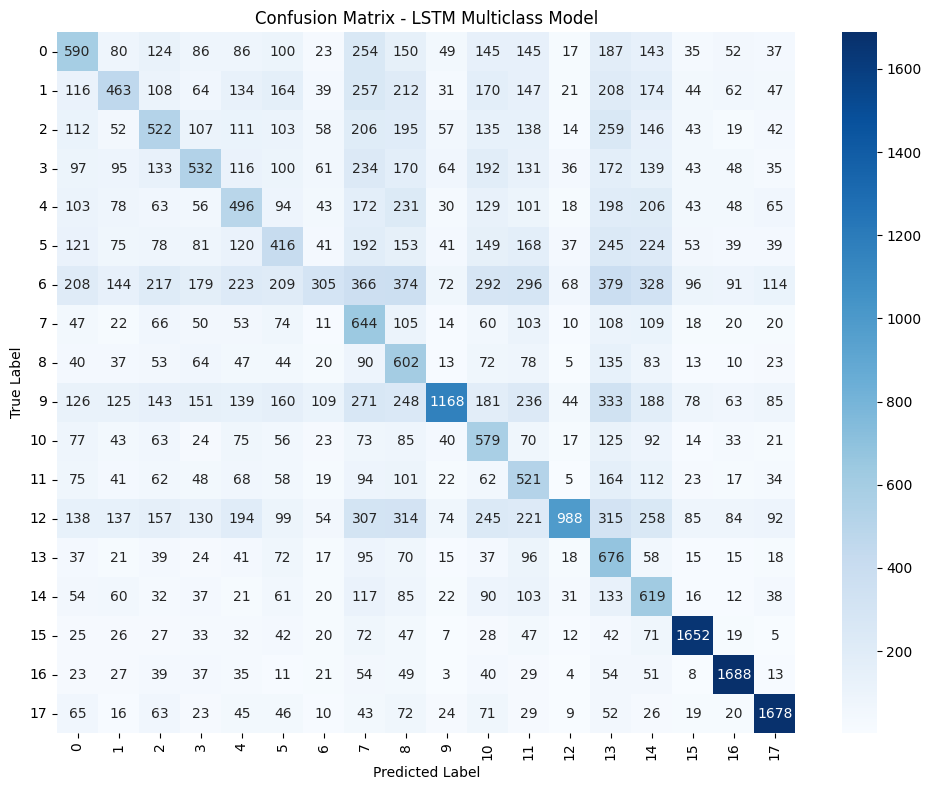

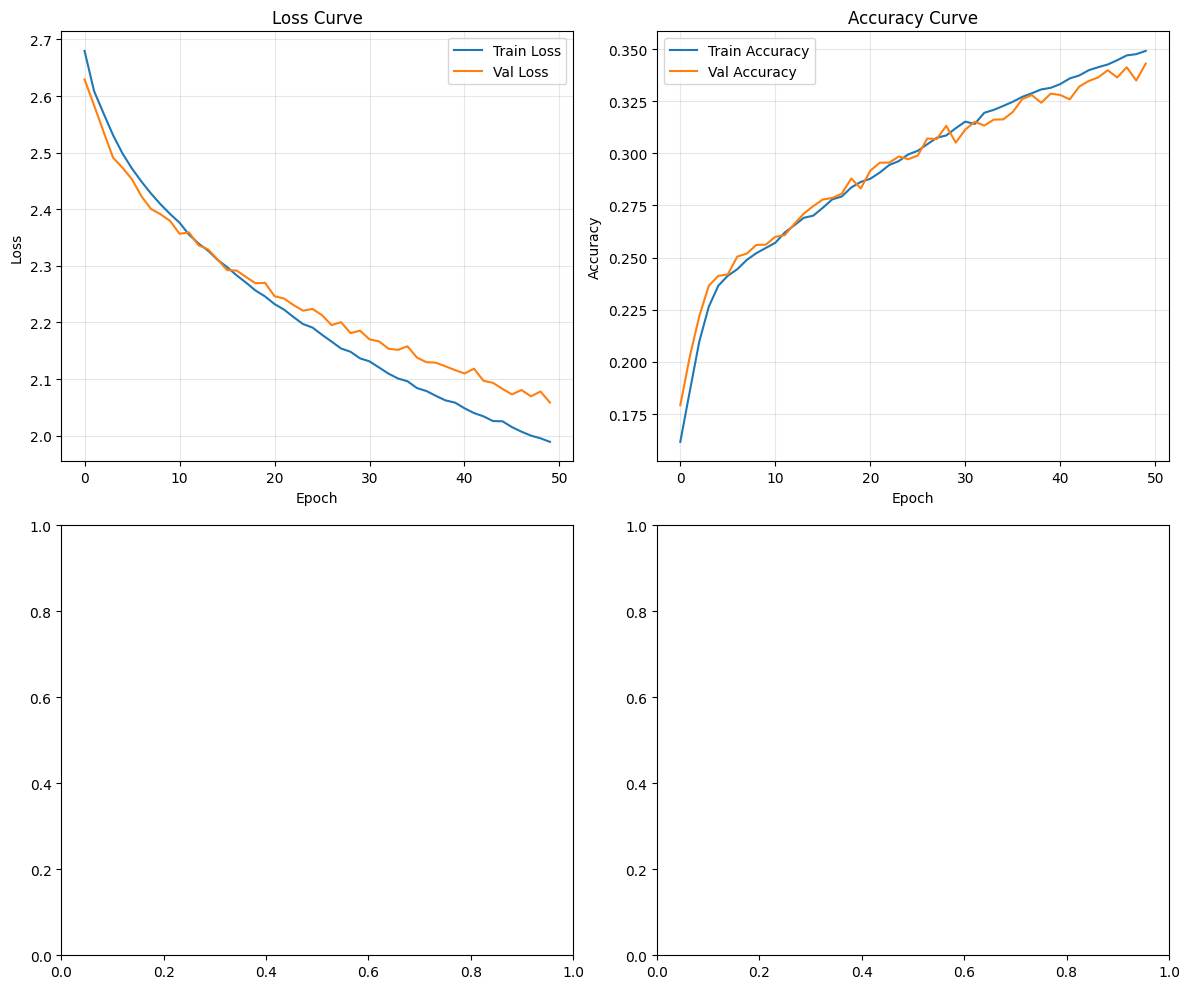

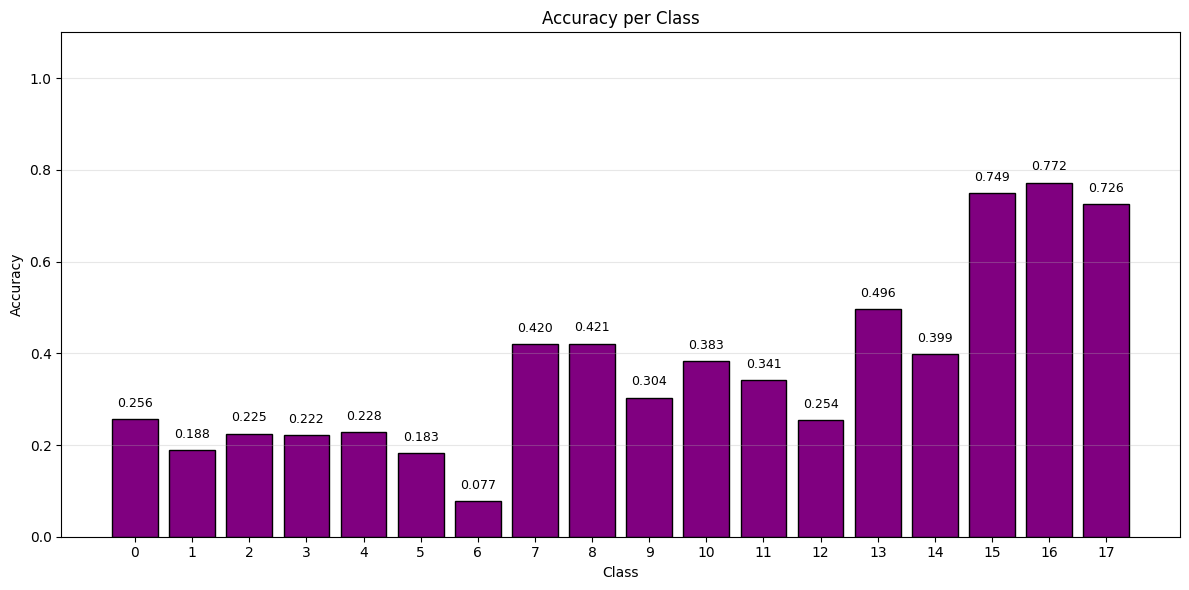

In [ ]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

if num_classes <= 20:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names if num_classes <= 10 else range(num_classes),
                yticklabels=class_names if num_classes <= 10 else range(num_classes))
    plt.title('Confusion Matrix - LSTM Multiclass Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    if num_classes > 10:
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print(f" Not showing confusion matrix for {num_classes} classes (more than 20)")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Loss
axes[0].plot(history_final.history['loss'], label='Train Loss')
axes[0].plot(history_final.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_final.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_final.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

if 'precision' in history_final.history:
    axes[2].plot(history_final.history['precision'], label='Train Precision')
    axes[2].plot(history_final.history['val_precision'], label='Val Precision')
    axes[2].set_title('Precision Curve')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Precision')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

if 'recall' in history_final.history:
    axes[3].plot(history_final.history['recall'], label='Train Recall')
    axes[3].plot(history_final.history['val_recall'], label='Val Recall')
    axes[3].set_title('Recall Curve')
    axes[3].set_xlabel('Epoch')
    axes[3].set_ylabel('Recall')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

correct_predictions = (y_pred == y_test)
accuracy_per_class = []

for cls in range(num_classes):
    cls_mask = (y_test == cls)
    if np.sum(cls_mask) > 0:
        cls_accuracy = np.sum(correct_predictions[cls_mask]) / np.sum(cls_mask)
        accuracy_per_class.append(cls_accuracy)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(num_classes), accuracy_per_class, color='purple', edgecolor='black')
plt.title('Accuracy per Class')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.xticks(range(num_classes), range(num_classes))
plt.ylim([0, 1.1])
plt.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accuracy_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()